In [1]:
import pandas as pd 
import numpy as np 
import os 
assets_dir = f"{os.getcwd()}/assets"

results_dir= os.path.join(assets_dir, "results")

indi_data = pd.read_csv(os.path.join(results_dir, "indi_data.csv"))
coop_data = pd.read_csv(os.path.join(results_dir, "coop_data.csv"))

global_data = pd.concat([indi_data, coop_data])

In [2]:
global_data.drop(columns=['Unnamed: 0'], inplace=True)

In [3]:
global_data.columns

Index(['Scenario', 'Objective Function', 'Number of Areas', 'Number of Agents',
       'Number of Users', 'Environment Type', 'Total Number of Clusters',
       'Total Nodes Visited', 'Visits per Node', 'Total Mission Time',
       'Total Energy Consumption', 'Total Distance Covered',
       'Average Visits per Node', 'Node Coverage Ratio',
       'Mission Efficiency per Energy',
       'Scaled Mission Efficiency per Energy (nodes per kWh)',
       'Mission Efficiency per Time',
       'Scaled Mission Efficiency per Time (nodes per hour)', 'Idle Ratio',
       'Total Makespan', 'Total Achievable DR',
       'Average Data Rate per Cluster', 'Average Makespan per Cluster',
       'Total Number of Constraints', 'Total Number of Variables',
       'Computational Time', 'Memory Usage'],
      dtype='object')

In [4]:
# grouped_means = global_data.groupby(['Scenario', 'Objective Function', 'Environment Type']).mean(numeric_only=True)
grouped_means = global_data.groupby(['Scenario', 'Objective Function']).mean(numeric_only=True)
grouped_means.to_csv('grouped_means.csv')

# PERFORMANCE RESULTS FOR THE GODS PLAN ALGORITHM 

/tmp/ipykernel_1425948/1108435072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(box_data, labels=env_types)
/tmp/ipykernel_1425948/1108435072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(box_data, labels=env_types)


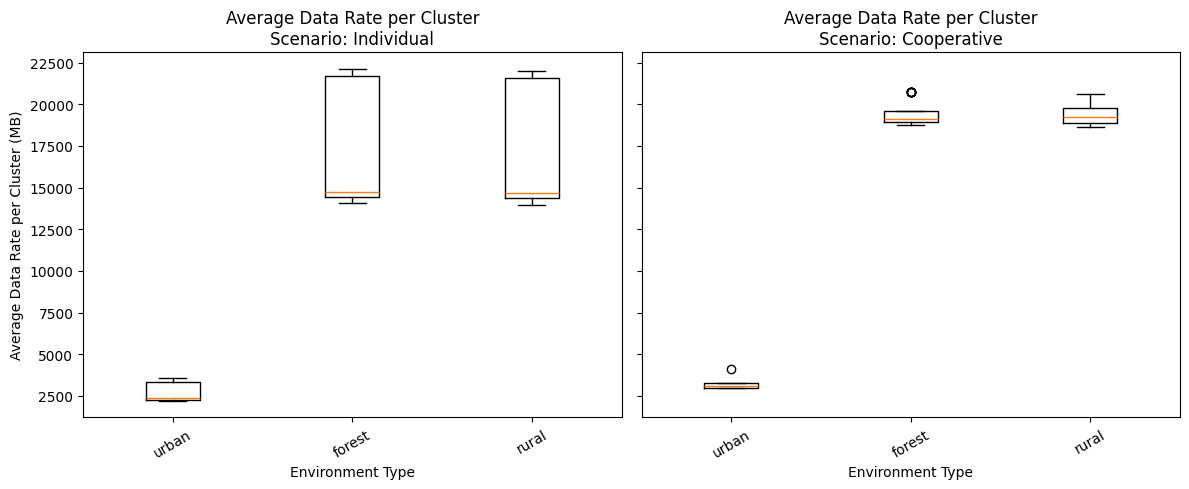

In [5]:
import matplotlib.pyplot as plt

scenarios = ['individual', 'cooperative']
env_types = global_data['Environment Type'].unique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, scenario in enumerate(scenarios):
    data = global_data[global_data['Scenario'] == scenario]
    # Prepare data for boxplot
    box_data = [data[data['Environment Type'] == env]['Average Data Rate per Cluster'] for env in env_types]
    axes[idx].boxplot(box_data, labels=env_types)
    axes[idx].set_title(f'Average Data Rate per Cluster\nScenario: {scenario.capitalize()}')
    axes[idx].set_xlabel('Environment Type')
    axes[idx].set_ylabel('Average Data Rate per Cluster (MB)' if idx == 0 else '')
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [6]:
#1 Operational Efficiency with GROUPED BAR CHART 
# Average all scenarios Use categories like Energy Cost, Time, distance makespan and coverage. 
# Two bars One for Collaborative and one for Individual 
average_indi = indi_data[['Average Data Rate per Cluster', 'Average Makespan per Cluster', 'Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time']].mean()
average_coop = coop_data[['Average Data Rate per Cluster', 'Average Makespan per Cluster', 'Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time']].mean()

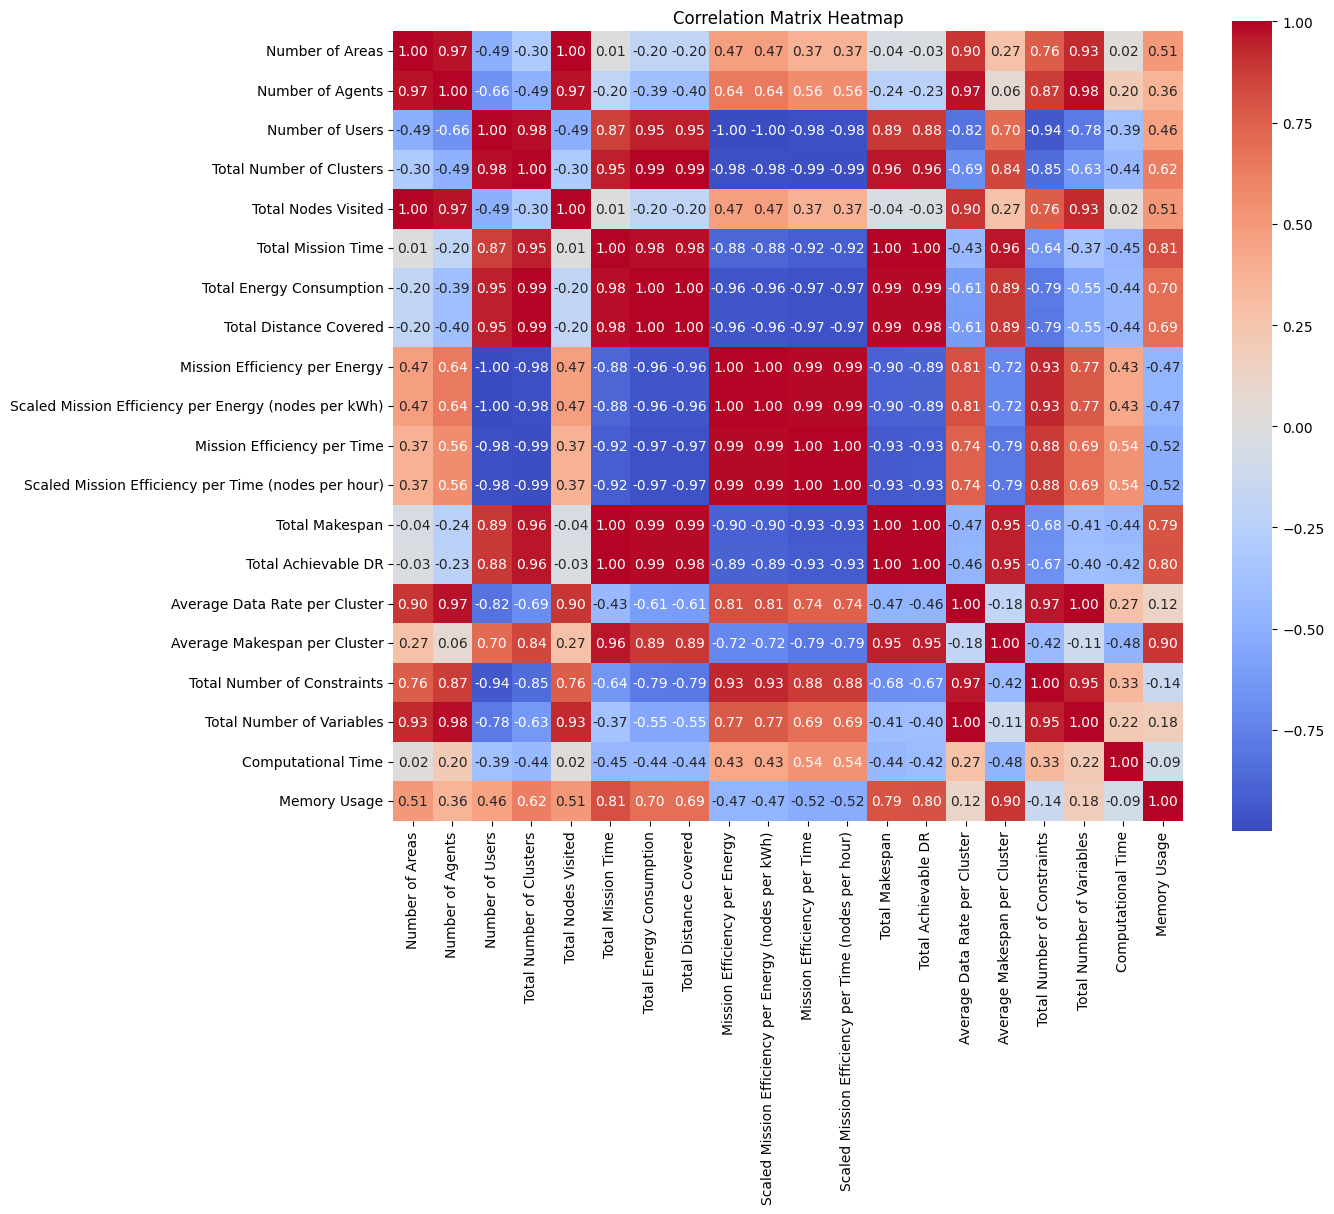

In [7]:
import seaborn as sns

exclude_cols = ['Scenario','Objective Function', 'Idle Ratio','Average Visits per Node','Node Coverage Ratio',
                # 'Total Number of Constraints','Computational Time','Total Makespan','Total Achievable DR']
]

 
ground_data = pd.read_csv('grouped_means.csv')
x = ground_data.drop(exclude_cols, axis=1)
import matplotlib.pyplot as plt

corr_matrix = x.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


In [8]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

def plotly_radar(normalized_df, metrics, strategy_names, colors):
    fig = go.Figure()
    print(normalized_df.describe())
    for strategy_name, color in zip(strategy_names, colors):
        values = normalized_df.loc[normalized_df['Objective Function'] == strategy_name, metrics].mean().tolist()
        values += values[:1]  # close the radar
        print(values)
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=metrics + [metrics[0]],
            fill='toself',
            name=strategy_name.capitalize(),
            line=dict(color=color)
        ))
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickvals=[0.25, 0.5, 0.75, 1],
                ticktext=['Lowest', '', '', 'Optimal']
            ),
            angularaxis=dict(
                tickmode='array',
                tickvals=list(range(len(metrics))),
                ticktext=metrics
            )
        ),
        showlegend=True,
        title="Comparison of Optimization Strategies"
    )
    fig.show()

exclude_cols = ['Scenario',  'Memory Usage','Mission Efficiency per Energy',
                'Mission Efficiency per Time','Number of Users','Number of Areas','Number of Agents','Total Number of Variables','Idle Ratio','Total Number of Clusters','Total Nodes Visited',
                'Scaled Mission Efficiency per Energy (nodes per kWh)','Scaled Mission Efficiency per Time (nodes per hour)','Average Visits per Node','Node Coverage Ratio',
                # 'Total Number of Constraints','Computational Time','Total Makespan','Total Achievable DR']
                'Total Number of Constraints','Computational Time','Average Makespan per Cluster','Average Data Rate per Cluster']


ground_data = pd.read_csv('grouped_means.csv')

scaler = MinMaxScaler()
x = ground_data.drop(exclude_cols, axis=1)
# metrics = ['Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time',  'Average Makespan per Cluster','Average Data Rate per Cluster']
metrics = ['Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time',  'Total Makespan','Total Achievable DR']

cost_metrics = ['Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time', 'Total Makespan']

normalized_df = x.copy() 

for metric in metrics: 
    normalized_df[metric] = scaler.fit_transform(normalized_df[[metric]])
    if metric in cost_metrics:
        normalized_df[metric] = 1 - normalized_df[metric]
    else:
        normalized_df[metric] = normalized_df[metric] 
    

# for metric in metrics: 
#     min_val = normalized_df[metric].min()
#     max_val = normalized_df[metric].max()
#     normalized_df[metric] = (normalized_df[metric] - min_val) / (max_val - min_val)

#     if metric in cost_metrics: 
#         normalized_df[metric] = 1 - normalized_df[metric]
#     else: 
#         normalized_df[metric] = normalized_df[metric] 

# labels = metrics
# num_vars = len(labels)

# angles = np.linspace(0,2*np.pi,num_vars,endpoint=False).tolist()
# angles += angles[:1] 

plotly_radar(normalized_df, metrics, ['energy', 'coverage'], ['green', 'blue'])


# fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# def add_to_radar(strategy_name, color): 
#     values = normalized_df.loc[normalized_df['Objective Function'] == strategy_name, metrics].mean().tolist()
#     values += values[:1]  # repeat the first value to close the radar chart
#     print(values)
#     print(angles)
#     ax.plot(angles, values, color=color, linewidth=2, label=strategy_name)
#     ax.fill(angles, values, color=color, alpha=0.25)

# add_to_radar('energy', 'green')
# add_to_radar('coverage', 'blue')

# ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# ax.set_rlabel_position(0)
# ax.set_ylim(0,1)
# ax.set_yticks([0.25, 0.5, 0.75, 1])
# ax.set_yticklabels(['Lowest', '', '', 'Optimal'])

# plt.title("Comparison of Optimization Strategies", size=20, color='blue', y=1.1)
# ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()


       Total Mission Time  Total Energy Consumption  Total Distance Covered  \
count            4.000000                  4.000000                4.000000   
mean             0.624754                  0.587316                0.585154   
std              0.460656                  0.489233                0.488629   
min              0.000000                  0.000000                0.000000   
25%              0.417519                  0.276303                0.273232   
50%              0.749509                  0.674632                0.670309   
75%              0.956744                  0.985644                0.982231   
max              1.000000                  1.000000                1.000000   

       Total Makespan  Total Achievable DR  
count    4.000000e+00             4.000000  
mean     6.205421e-01             0.369168  
std      4.676576e-01             0.471930  
min     -2.220446e-16             0.000000  
25%      3.898026e-01             0.011310  
50%      7.410842e

Number of Areas  Scenario     Number of Agents
50               cooperative  4                    1632.0
                              6                    2110.0
100              cooperative  4                    3851.0
                              6                    5172.0
150              cooperative  4                    6144.0
                              6                    8068.0
200              cooperative  4                    8223.0
                              6                   10734.0
Name: Total Number of Variables, dtype: float64


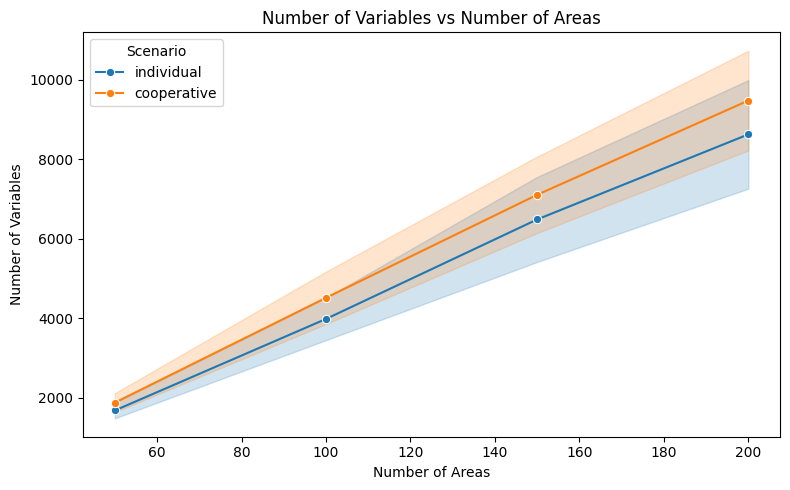

In [34]:
import seaborn as sns


comp_times_indi = indi_data.groupby(['Number of Areas', 'Scenario','Number of Agents'])['Total Number of Variables'].median()
comp_times_coop = coop_data.groupby(['Number of Areas', 'Scenario','Number of Agents'])['Total Number of Variables'].median()
comp_times_mean = pd.concat([comp_times_indi, comp_times_coop], axis=0)
print(comp_times_coop)
# comp_time_means = global_data.groupby(['Number of Areas', 'Scenario'])['Scaled Mission Efficiency per Energy (nodes per kWh)'].mean().unstack()

# # Prepare data for seaborn lineplot
comp_time_reset = comp_times_mean.reset_index()
comp_time_reset.rename(columns={'Total Number of Variables': 'Variables'}, inplace=True)

plt.figure(figsize=(8, 5))
sns.lineplot(data=comp_time_reset, x='Number of Areas', y='Variables', hue='Scenario', marker='o')
plt.xlabel('Number of Areas')
plt.ylabel('Number of Variables')
plt.title('Number of Variables vs Number of Areas')
plt.tight_layout()
plt.show()

In [23]:
comp_times_coop.median()

Number of Areas  Scenario   
50               cooperative     26.217822
100              cooperative    135.196301
150              cooperative    257.274248
200              cooperative    337.045523
Name: Computational Time, dtype: float64

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 

comp_time_means = global_data.groupby(['Number of Areas', 'Scenario'])['Total Number of Constraints'].mean().unstack()

# Prepare data for seaborn lineplot
comp_time_reset = comp_time_means.reset_index().melt(id_vars='Number of Areas', 
                                                     value_vars=['individual', 'cooperative'],
                                                     var_name='Scenario', 
                                                     value_name='Total Number of Constraints')

plt.figure(figsize=(8, 5))
sns.lineplot(data=comp_time_reset, x='Number of Areas', y='Total Number of Constraints', hue='Scenario', marker='o')
plt.xlabel('Number of Areas')
plt.ylabel('Total Number of Constraints')
plt.title('Total Number of Constraints vs Number of Areas')
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 

comp_time_means = global_data.groupby(['Number of Agents', 'Scenario'])['Total Makespan'].mean().unstack()

# Prepare data for seaborn lineplot
comp_time_reset = comp_time_means.reset_index().melt(id_vars='Number of Agents', 
                                                     value_vars=['individual', 'cooperative'],
                                                     var_name='Scenario', 
                                                     value_name='Total Makespan')

plt.figure(figsize=(8, 5))
sns.lineplot(data=comp_time_reset, x='Number of Agents', y='Total Makespan', hue='Scenario', marker='o')
plt.xlabel('Number of Agents')
plt.ylabel('Total Makespan (minutes)')
plt.title('Total Makespan vs Number of Agents')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt 

# Group by 'Number of Areas' and 'Scenario', then calculate mean computational time
comp_time_means = global_data.groupby(['Number of Areas', 'Scenario'])['Computational Time'].mean().unstack()

plt.figure(figsize=(8, 5))
plt.plot(comp_time_means.index, comp_time_means['individual'], marker='o', label='Individual')
plt.plot(comp_time_means.index, comp_time_means['cooperative'], marker='o', label='Cooperative')
plt.xlabel('Number of Areas')
plt.ylabel('Average Computational Time (Seconds)')
plt.title('Average Computational Time vs Number of Areas')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt 

exclude_cols = ['Scenario', 'Objective Function', 'Environment Type', 'Visits per Node', 'Memory Usage','Mission Efficiency per Energy',
                'Mission Efficiency per Time','Number of Users','Number of Areas','Number of Agents','Node Coverage Ratio',
                'Total Makespan','Total Number of Variables','Idle Ratio']


metric_system = {
    'Total Number of Clusters':'Clusters',
    'Total Mission Time': 'Minutes', 
    'Total Energy Consumption':'Wh',
    'Total Distance Covered':'Km',
    'Average Visits per Node':'Visits',
    'Total Achievable DR':'MB',
    'Average Data Rate per Cluster':'MB',
    'Average Makespan per Cluster':'Minutes',
    'Total Number of Constraints':'Constraints',
    'Computational Time':'Seconds',
    }
numeric_cols = [col for col in global_data.columns if col not in exclude_cols and global_data[col].dtype != 'O']

for metric in numeric_cols:
    melted_df = pd.melt(global_data, 
                        value_vars=[metric], 
                        id_vars=['Scenario'], 
                        var_name='Metric',
                        value_name='Value'
            )

    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(5, 5))

    ax = sns.barplot(data=melted_df, x='Metric', y='Value', hue='Scenario', palette='viridis')
    ax.set_title('Comparison of Cooperative vs Individual Scenarios', fontsize=10, weight='bold')
    ax.set_xlabel('', fontsize=14)
    ax.set_ylabel(metric_system[metric] if metric in metric_system else '', fontsize=14)
    ax.tick_params(axis='x',labelsize=12)

    plt.tight_layout() 

    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Select numeric columns to plot (excluding identifier columns)
exclude_cols = ['Scenario', 'Objective Function', 'Environment Type', 'Visits per Node']
numeric_cols = [col for col in global_data.columns if col not in exclude_cols and global_data[col].dtype != 'O']

# Group by Scenario and calculate mean for each metric
grouped_means = global_data.groupby('Scenario')[numeric_cols].mean()

# Plot each metric as a grouped bar plot
for metric in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.bar(['Individual', 'Cooperative'], grouped_means.loc[['individual', 'cooperative'], metric], color=['tab:blue', 'tab:orange'])
    plt.title(f'{metric}: Individual vs Cooperative')
    plt.ylabel('Mean Value')
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Select the metrics to plot
metrics = ['Total Energy Consumption', 'Total Distance Covered', 'Total Mission Time']

# Calculate means for each scenario
mean_indi = indi_data[metrics].mean()
mean_coop = coop_data[metrics].mean()

# Prepare data for plotting
values = [mean_indi.values, mean_coop.values]
labels = ['Individual', 'Cooperative']

x = np.arange(len(metrics))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, mean_indi, width, label='Individual')
rects2 = ax.bar(x + width/2, mean_coop, width, label='Cooperative')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Mean Value')
ax.set_title('Comparison of Metrics: Individual vs Cooperative')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# one_global = [] 
# for file in os.listdir(results_dir): 
#     print(file)
#     if file.endswith('.csv'): 
#         file_path = os.path.join(results_dir, file)
#         df = pd.read_csv(file_path)
#         one_global.append(df) 

# global_data = pd.concat(one_global) 
# global_data.describe()
# global_data.shape
# global_data.head()
# indi_data = global_data.groupby('Scenario').get_group('individual')
# coop_data = global_data.groupby('Scenario').get_group('cooperative')
# indi_data.to_csv(f"{results_dir}/indi_data.csv")
# coop_data.to_csv(f"{results_dir}/coop_data.csv")
# categorical_columns =  [col for col in global_data.columns if global_data[col].name in global_data.select_dtypes(include='category').columns]
# for col in categorical_columns: 
#     global_data[col] = global_data[col].cat.codes 
# one_global.to_csv(os.path.join(results_dir, 'global_results.csv'), index=False)

In [ ]:
x = global_data[['Scenario', 'Objective Function' ,'Total Energy Consumption', 
                 'Total Distance Covered', 'Total Mission Time', 'Total Nodes Visited',
                 'Scaled Mission Efficiency per Energy (nodes per kWh)', 'Scaled Mission Efficiency per Time (nodes per hour)', 
                 'Total Number of Constraints','Total Number of Variables', 
                  'Computational Time', 'Memory Usage', 'Idle Ratio', 'Total Number of Clusters']]

In [ ]:
x.head()

In [ ]:
grouped_results = x.groupby(['Scenario', 'Objective Function']).mean()
grouped_results

In [ ]:
for group in grouped_results: 
    print(group)